## Top Pop

In [3]:
import pandas as pd

billboard = pd.read_csv("tables/billboard.csv", encoding="unicode_escape")
billboard["week"] = pd.to_datetime(billboard["week"], format="%m/%d/%Y")
billboard["entry_date"] = pd.to_datetime(billboard["entry_date"], format="%m/%d/%Y")

In [4]:
min_year = billboard["week"].dt.year.min()
max_year = billboard["week"].dt.year.max()
print(f"Data cover years from {min_year} to {max_year}")

Data cover years from 1940.0 to 2016.0


In [5]:
longest_charting = billboard.sort_values(
    by="overall_total_weeks", ascending=False
).iloc[0]
print(longest_charting["song"])

Radioactive


In [6]:
latest_date = billboard["week"].max()
top_song_recent = billboard[
    (billboard["week"] == latest_date) & (billboard["this_week_position"] == 1)
]

print(top_song_recent["song"])

0    Hello
Name: song, dtype: object


Part A

1. The data cover years from 1940.0 to 2016.0


2. 'Week_peak' refers to the highest ranking achieved during that week, while 'overall_peak' refers to the highest ranking the song has achieved throughout the entire history of the chart.

3. The song that has been in the charts for the longest number of weeks is 'Radioactive'.

4. The top song in the most recent chart is 'Hello'.

In [7]:
import plotnine as p9

# Beatles Dominance in 1964
beatles = billboard[
    (billboard.artist == "BEATLES")
    & (billboard.week >= "1964-02-01")
    & (billboard.week <= "1964-06-01")
].reset_index()

plot_beatles = (
    p9.ggplot(
        beatles, p9.aes("week", "this_week_position", group="song", colour="song")
    )
    + p9.scale_y_reverse()
    + p9.geom_point()
    + p9.geom_line()
    + p9.scale_x_datetime(breaks="1 month", date_labels="%b")
    + p9.ggtitle("Beatles Dominance in 1964")
    + p9.ylab("Position")
)

p9.ggsave(plot_beatles, filename="beatles.pdf")

d:\Python\amber.github.io\.venv\Lib\site-packages\plotnine\scales\scale_datetime.py:87: FutureWarning: Passing a string to `breaks` will not work in future versions. Use `date_breaks='1 month'`
d:\Python\amber.github.io\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
d:\Python\amber.github.io\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: beatles.pdf


Possible aesthetics to display rank:

1. Using size to display rank

2. Using color to display rank

3. Using both

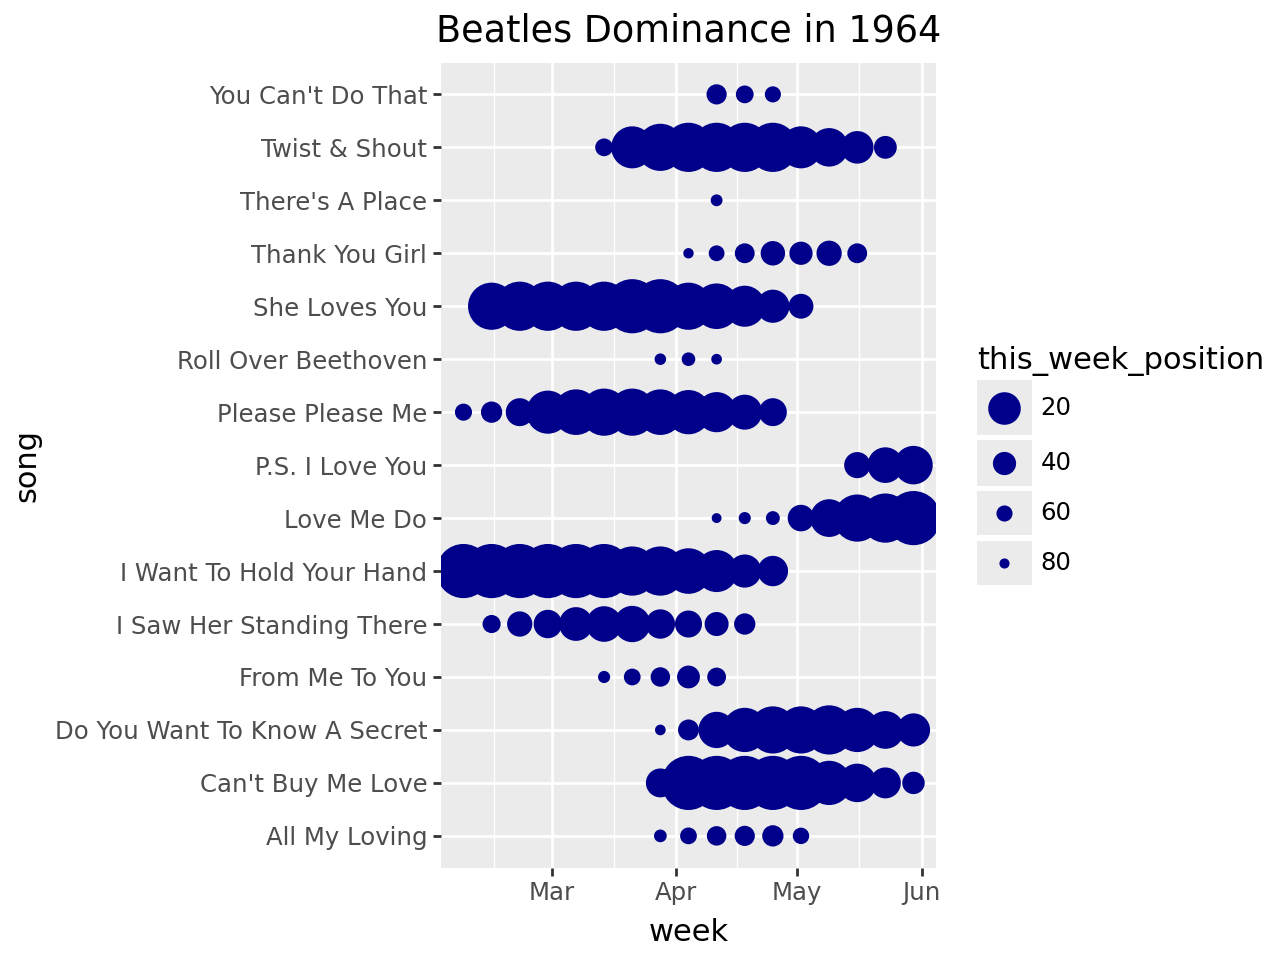

In [8]:
plot_size = (
    p9.ggplot(beatles, p9.aes(x="week", y="song", size="this_week_position"))
    + p9.geom_point(color="darkblue")
    + p9.scale_size(range=(10, 1))
    + p9.scale_x_datetime(date_breaks="1 month", date_labels="%b")
    + p9.ggtitle("Beatles Dominance in 1964")
)

plot_size


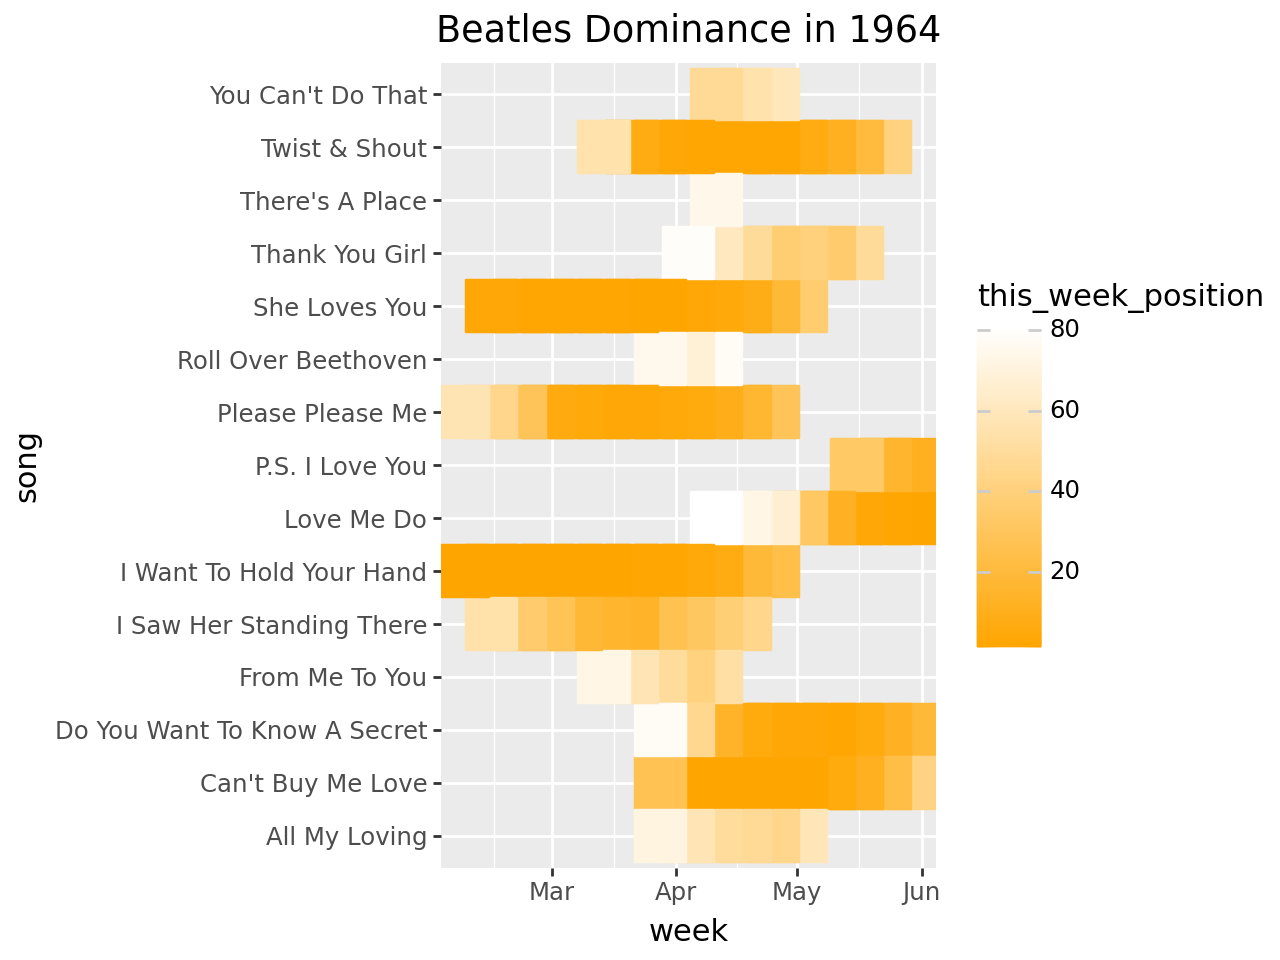

In [9]:
# Color Gradient
plot_color = (
    p9.ggplot(beatles, p9.aes(x="week", y="song", color="this_week_position"))
    + p9.geom_point(size=10, shape="s")
    + p9.scale_color_gradient(low="orange", high="white")
    + p9.scale_x_datetime(date_breaks="1 month", date_labels="%b")
    + p9.ggtitle("Beatles Dominance in 1964")
)

plot_color

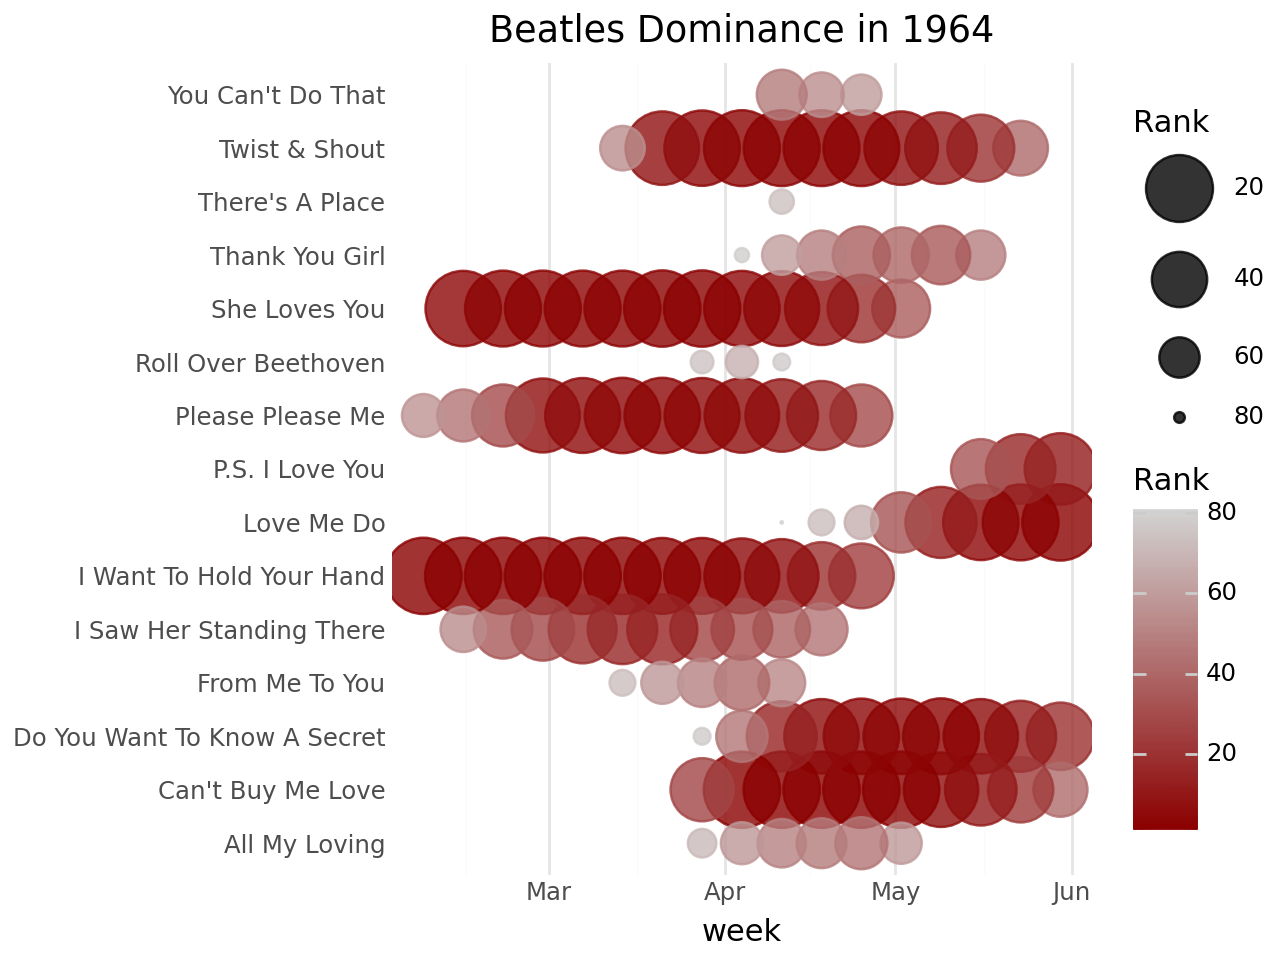

In [10]:
plot_redundant = (
    p9.ggplot(
        beatles,
        p9.aes(
            x="week", y="song", size="this_week_position", color="this_week_position"
        ),
    )
    + p9.geom_point(alpha=0.8)
    + p9.scale_size_area(trans="reverse", max_size=15, name="Rank")
    + p9.scale_color_gradient(low="#8B0000", high="#D3D3D3", name="Rank")
    + p9.scale_x_datetime(date_breaks="1 month", date_labels="%b")
    + p9.theme_minimal()
    + p9.theme(panel_grid_major_y=p9.element_blank())
    + p9.ggtitle("Beatles Dominance in 1964")
    + p9.ylab("")
)

plot_redundant

What do you notice? What aesthetic makes it easiest to see the pattern over time? What makes it hardest? Does combining aesthetics make it better? What makes the original plot so good?

- The original plot is the easiest way to see the pattern over time. Color is the hardest. Combining color and size is slightly worse as the information is redundant. Original plot is so good because the original image used position along a common scale. Position is the highest noticeable, while area and color saturation seems to have lower levels.

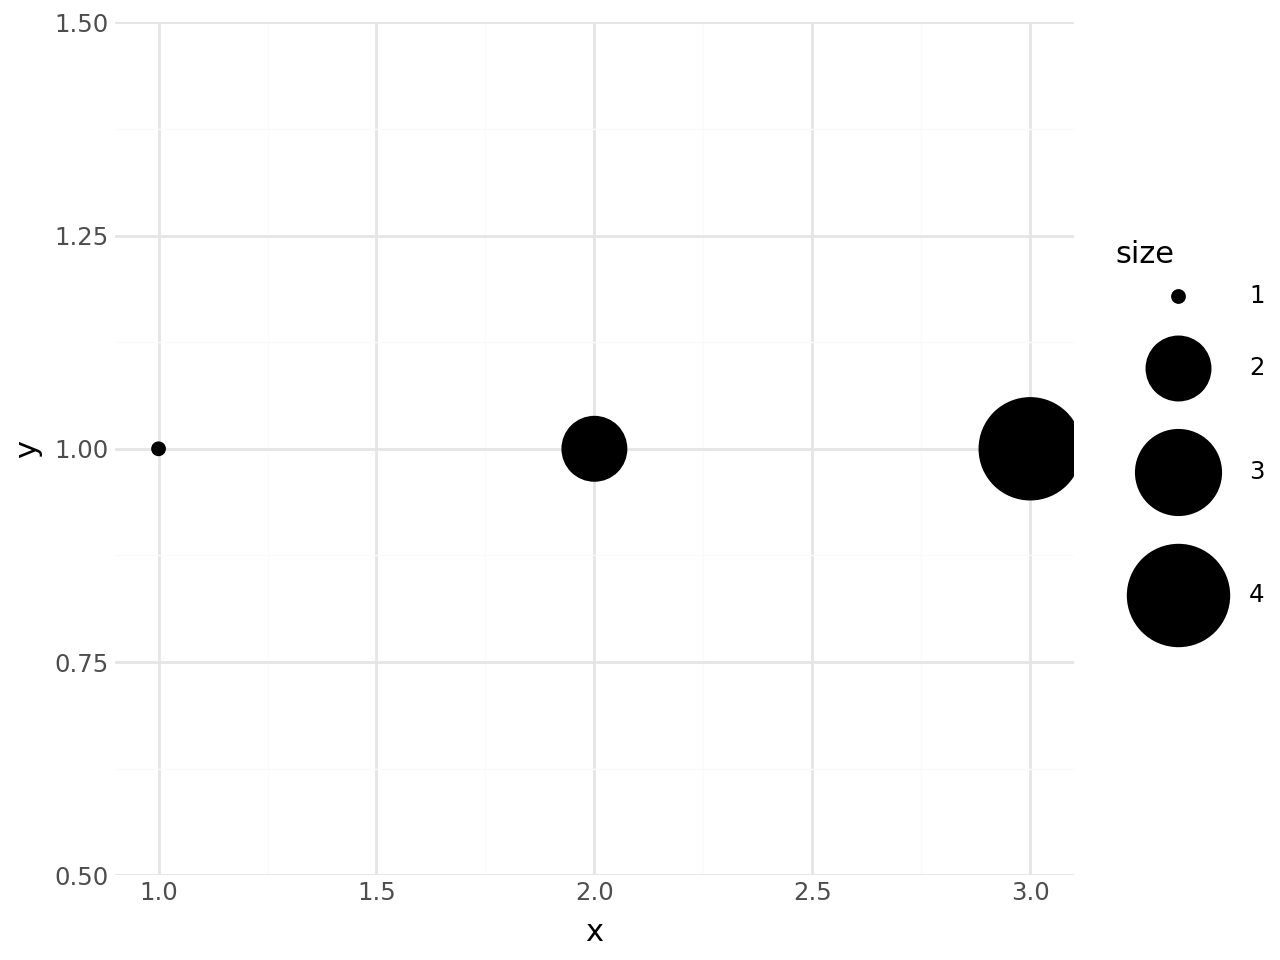

In [11]:
import pandas as pd
from plotnine import *

df = pd.DataFrame(
    {
        "x": [1, 2, 3],
        "y": [1, 1, 1],
        "size": [1, 2, 4],
        # "size": [1, 1.414, 2]
    }
)

(
    ggplot(df, aes(x="x", y="y", size="size"))
    + geom_point()
    + scale_size_continuous(range=(2, 20))
    + theme_minimal()
)


You’ve probably used size as one of the aesthetics - but what is size really 
mapped to? Create a small experiment to determine whether size is mapped to 
radius or area? Which do you think it should be mapped to?

- Size is mapped to radius. As the point with size = 4 appear much larger than points with size = 2. Visually, the increase is closer to a fourfold increase in area, rather than a twofold increase.

- It's hard to say. I am not sensitive to the area. It looks like the size is what the area is for me (though it is not).

To further explore, I want to know the trajectory of 'See You Again (Wiz Khalifa ft. Charlie Puth)' on the Hot 100 chart. (I really love this song since my middle school and have repeated it over 479 times)

In [12]:
# in case same name
target_song_data = billboard[
    (billboard["song"] == "See You Again")
    & (billboard["artist"].str.contains("CHARLIE PUTH", case=False))
].copy()

print(target_song_data["artist"].unique())

['WIZ KHALIFA featuring CHARLIE PUTH']


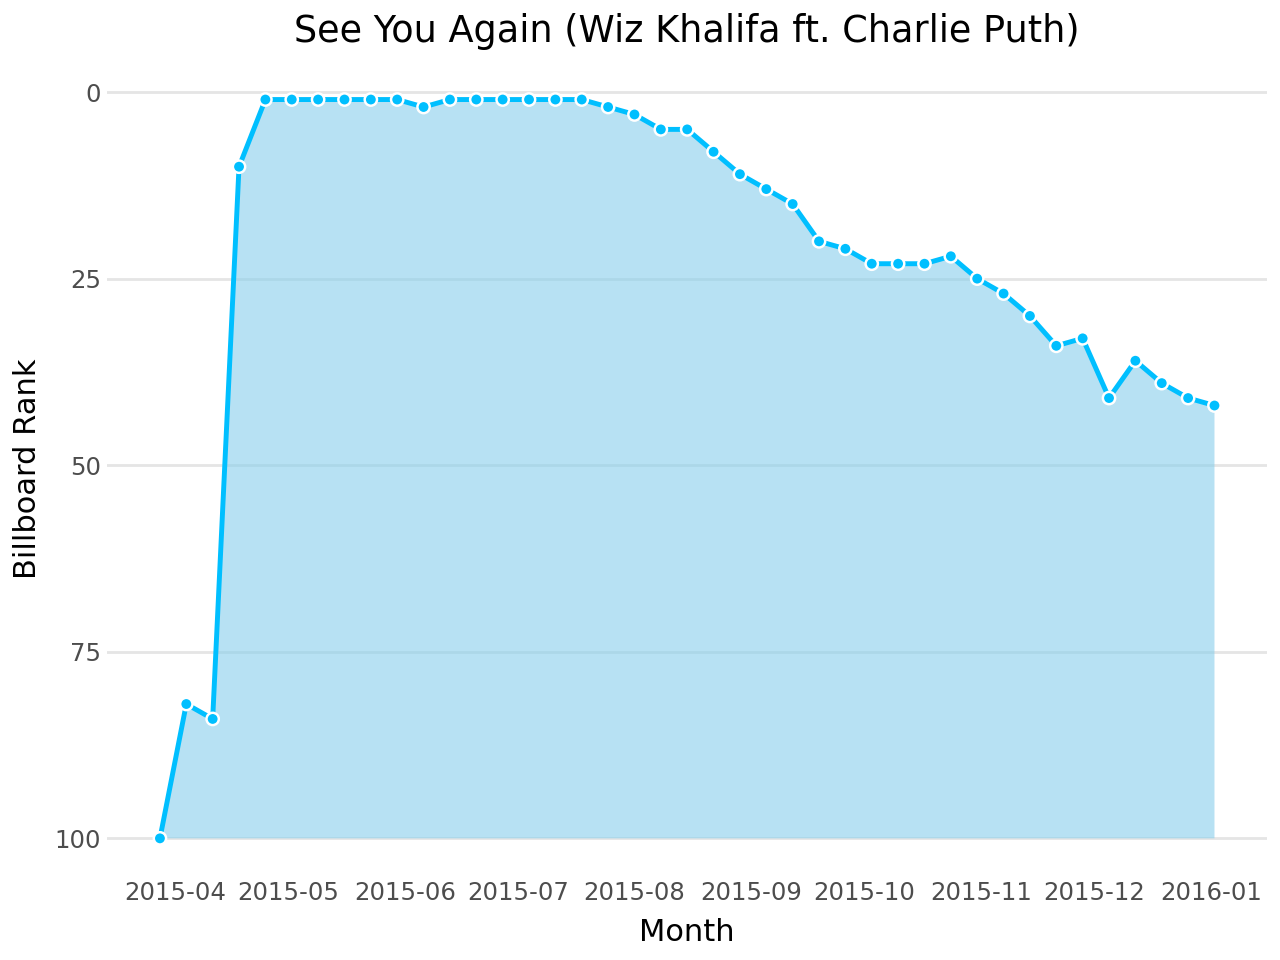

In [ ]:
plot_see_you_again = (
    p9.ggplot(target_song_data, p9.aes(x="week", y="this_week_position"))
    + p9.geom_ribbon(
        p9.aes(ymin=100, ymax="this_week_position"), fill="#87CEEB", alpha=0.6
    )
    + p9.geom_line(color="#00BFFF", size=1)
    + p9.geom_point(color="white", fill="#00BFFF", size=2, stroke=0.5)
    + p9.scale_y_reverse(limits=(100, 1))
    + p9.scale_x_datetime(date_breaks="1 months", date_labels="%Y-%m")
    + p9.labs(
        title="See You Again (Wiz Khalifa ft. Charlie Puth)",
        x="Month",
        y="Billboard Rank",
    )
    + p9.theme_minimal()
    + p9.theme(
        panel_grid_major_x=p9.element_blank(),
        panel_grid_minor=p9.element_blank(),
        # axis_text_x=p9.element_text(angle=45, ha="right"),
    )
)

plot_see_you_again

Alternate 1 for See You Again:

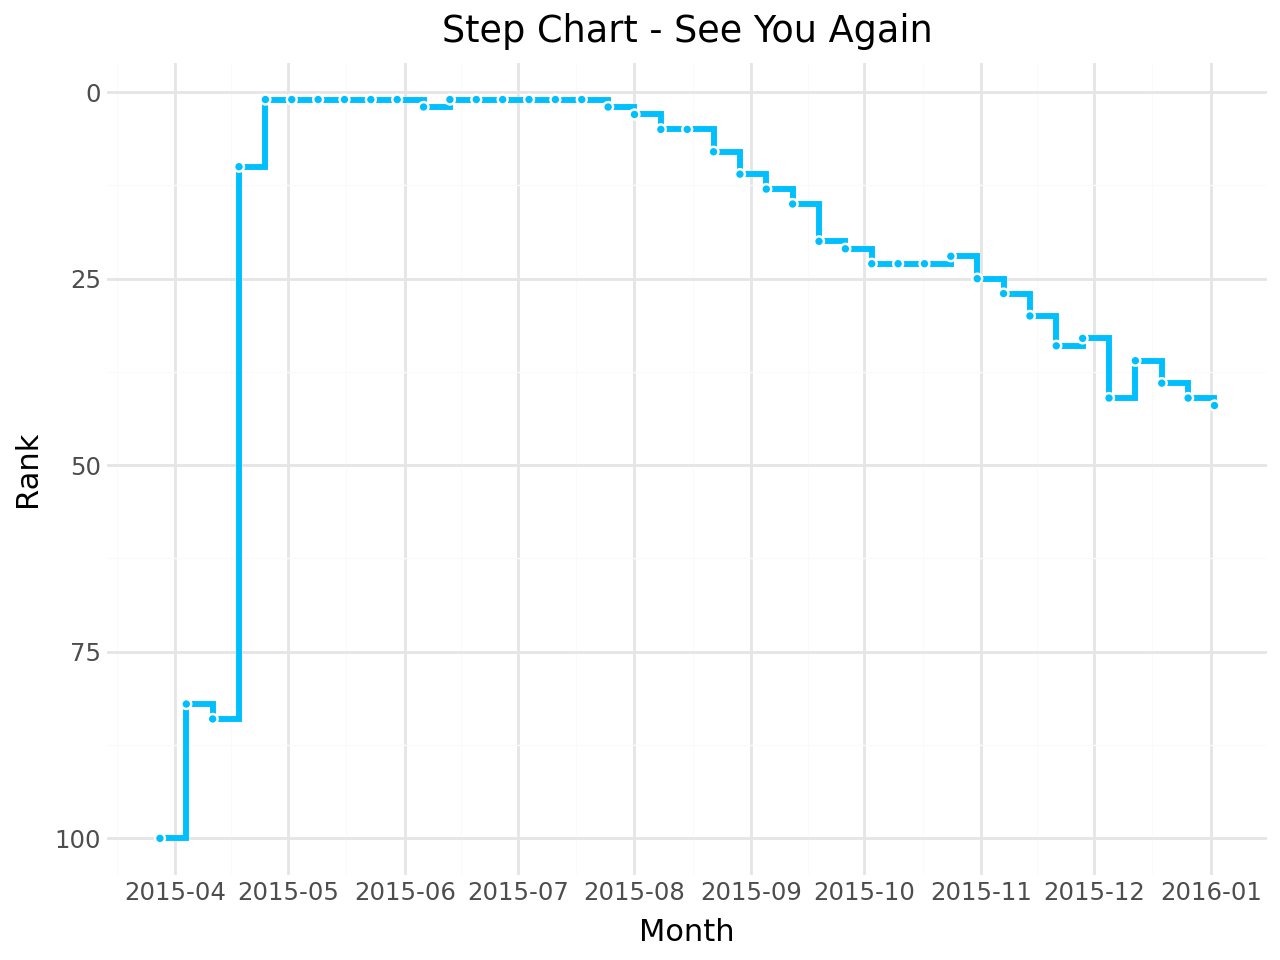

In [30]:
plot_see_you_step = (
    p9.ggplot(target_song_data, p9.aes(x="week", y="this_week_position"))
    + p9.geom_step(color="#00BFFF", size=1.2, direction="hv")
    + p9.geom_point(color="white", fill="#00BFFF", size=1.5, stroke=0.5)
    + p9.scale_y_reverse(limits=(100, 1))
    + p9.scale_x_datetime(date_breaks="1 months", date_labels="%Y-%m")
    + p9.labs(title="Step Chart - See You Again", x="Month", y="Rank")
    + p9.theme_minimal()
)
plot_see_you_step

ALternate 2 for See You Again:

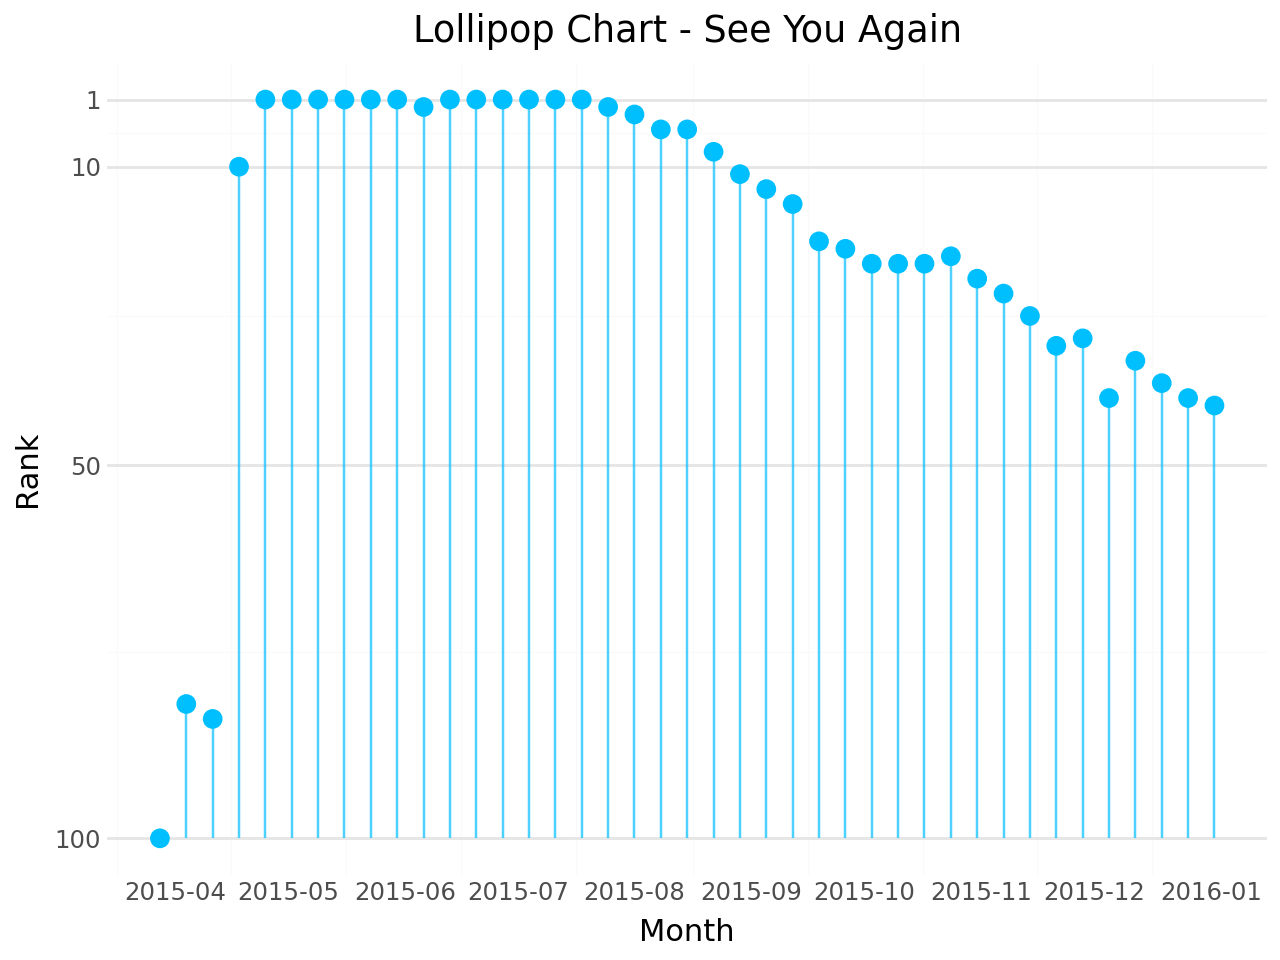

In [31]:
plot_see_you_lollipop = (
    p9.ggplot(target_song_data, p9.aes(x="week", y="this_week_position"))
    + p9.geom_segment(
        p9.aes(xend="week", yend=100), color="#00BFFF", size=0.5, alpha=0.7
    )
    + p9.geom_point(color="#00BFFF", size=3)
    + p9.scale_y_reverse(limits=(100, 1), breaks=[1, 10, 50, 100])
    + p9.scale_x_datetime(date_breaks="1 months", date_labels="%Y-%m")
    + p9.labs(title="Lollipop Chart - See You Again", x="Month", y="Rank")
    + p9.theme_minimal()
    + p9.theme(panel_grid_major_x=p9.element_blank())
)
plot_see_you_lollipop

Next, I would like to look into Charlie Puth's career trajectories.

In [15]:
# filter
artist_mask = billboard["artist"].str.contains("Charlie Puth", case=False, na=False)
cp_career = billboard[artist_mask].copy()

print(f"Songs from Charlie Puth: {cp_career['song'].nunique()}")
print(cp_career["song"].unique())


Songs from Charlie Puth: 4
['See You Again' 'One Call Away' 'Marvin Gaye'
 'Nothing But Troubles (Instagram Models)']


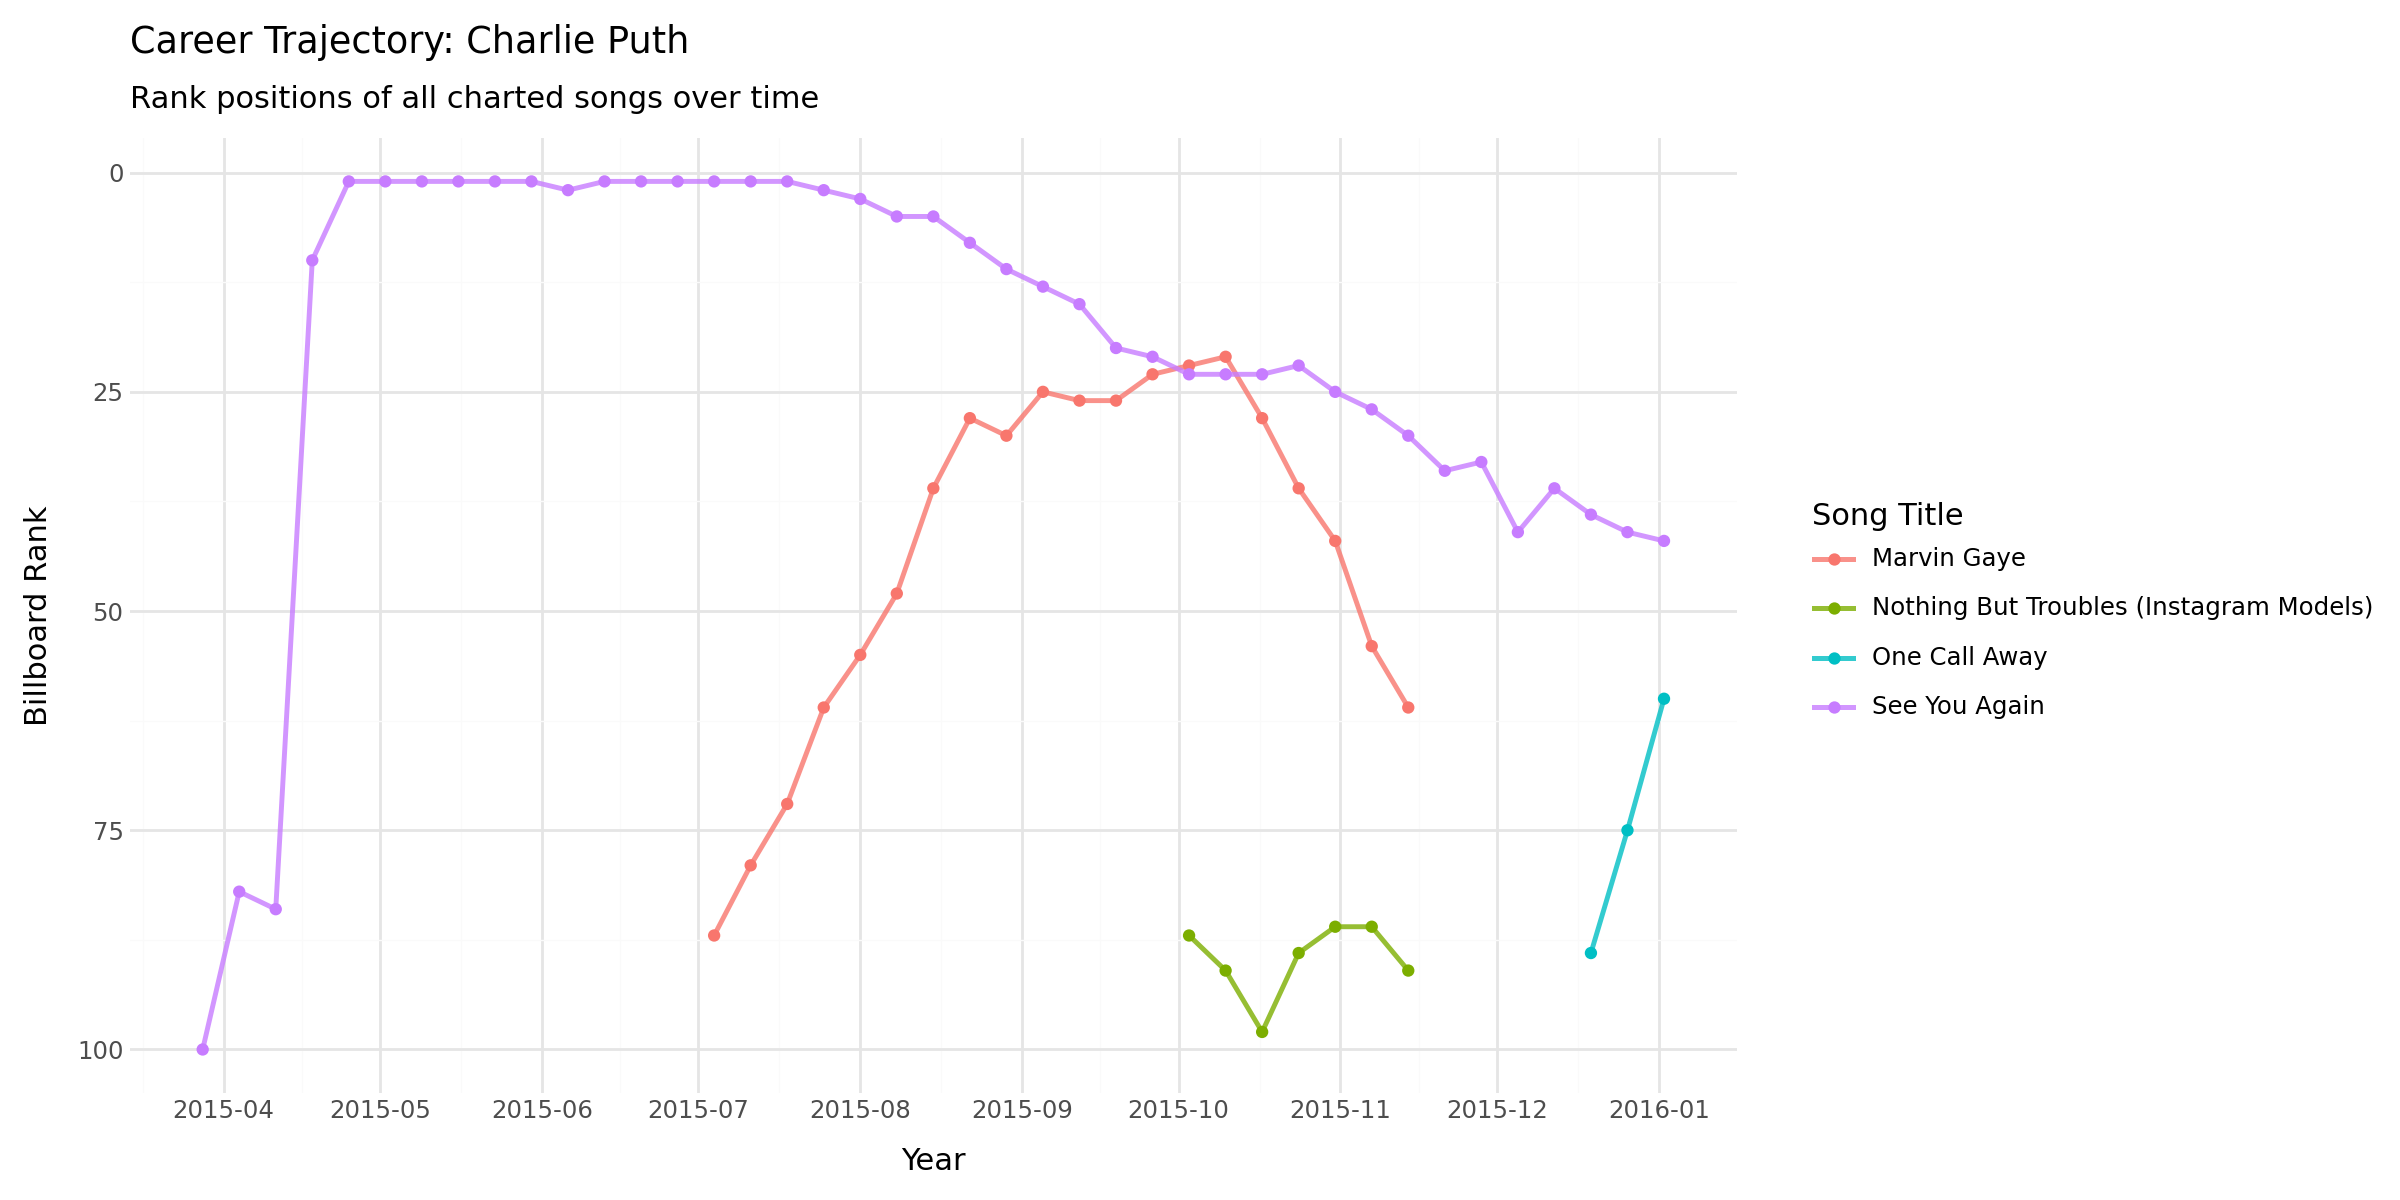

In [24]:
plot_career = (
    p9.ggplot(
        cp_career, p9.aes(x="week", y="this_week_position", group="song", color="song")
    )
    + p9.geom_line(size=1, alpha=0.8)
    + p9.geom_point(size=1.5)
    + p9.scale_y_reverse(limits=(100, 1))
    + p9.scale_x_datetime(date_breaks="1 months", date_labels="%Y-%m")
    + p9.labs(
        title="Career Trajectory: Charlie Puth",
        subtitle="Rank positions of all charted songs over time",
        x="Year",
        y="Billboard Rank",
        color="Song Title",
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(12, 6),
        legend_position="right",
    )
)

plot_career

Alternate 1 for Charlie Puth:

In [ ]:
artist_mask = billboard["artist"].str.contains("Charlie Puth", case=False, na=False)
cp_career = billboard[artist_mask].copy()
song_order = (
    cp_career.sort_values("week")
    .groupby("song")["week"]
    .min()
    .sort_values()
    .index.tolist()
)
cp_career["song_ordered"] = pd.Categorical(
    cp_career["song"], categories=song_order, ordered=True
)

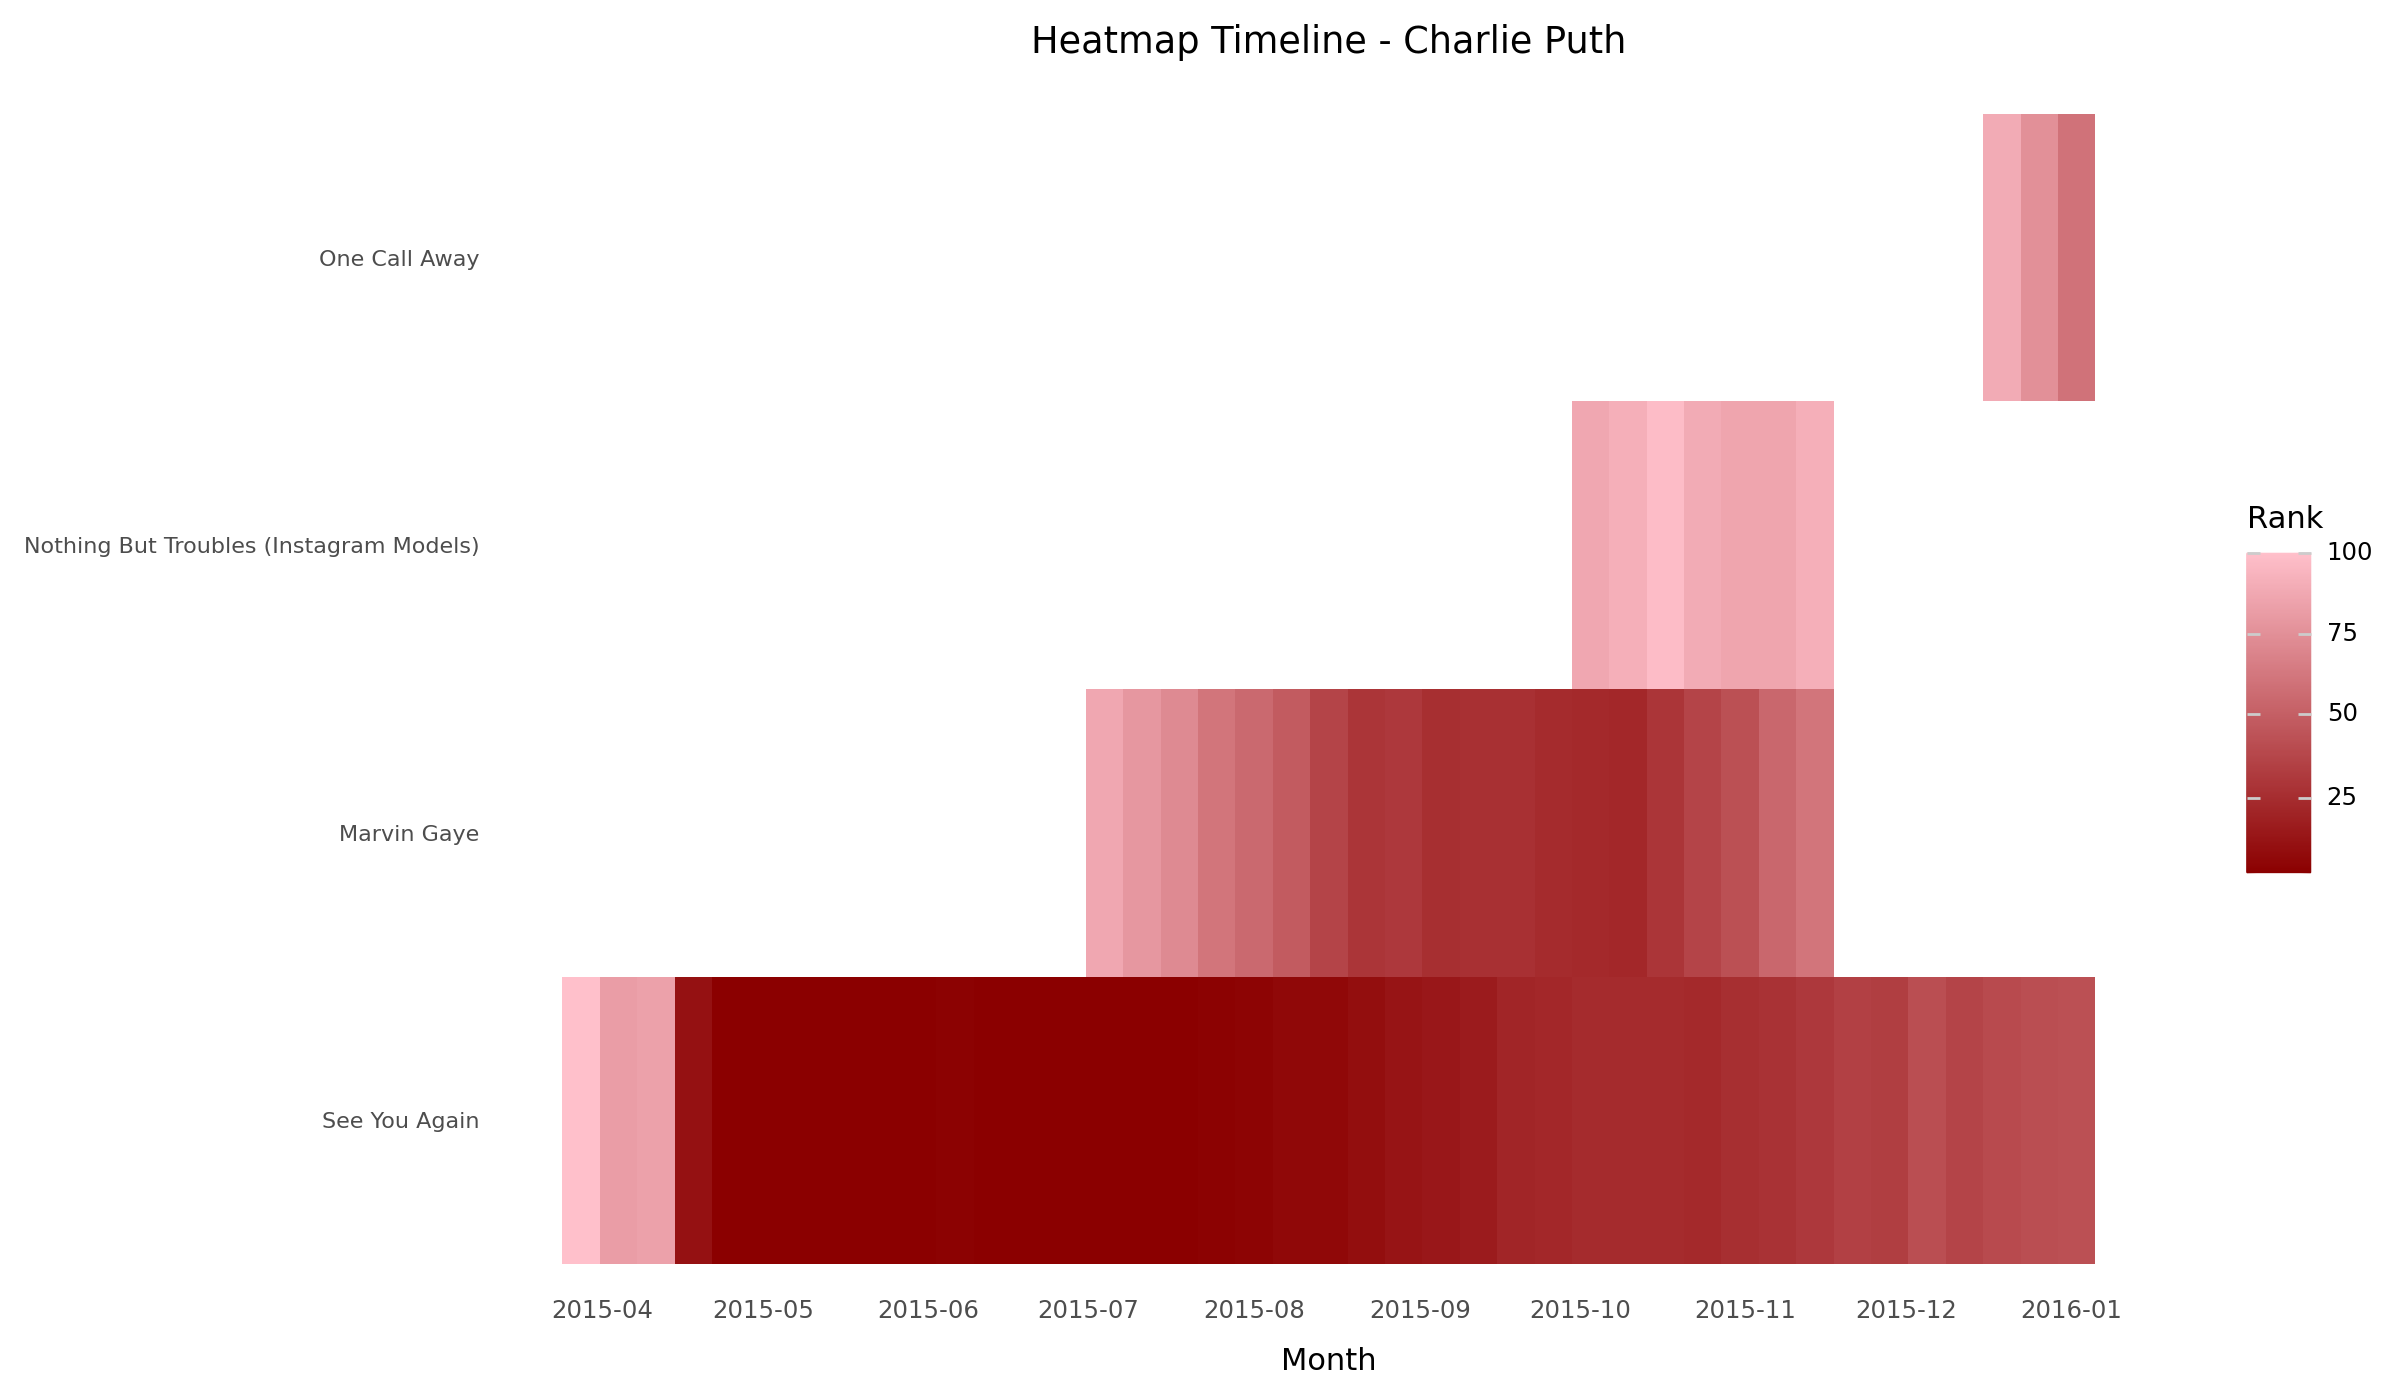

In [34]:
plot_cp_heatmap = (
    p9.ggplot(cp_career, p9.aes(x="week", y="song_ordered", fill="this_week_position"))
    + p9.geom_tile(height=1)
    + p9.scale_fill_gradient(
        low="#8B0000", high="#FFC0CB", limits=(1, 100), name="Rank"
    )
    + p9.scale_x_datetime(date_breaks="1 month", date_labels="%Y-%m")
    + p9.labs(
        title="Heatmap Timeline - Charlie Puth",
        x="Month",
        y="",
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(12, 7),
        panel_grid=p9.element_blank(),
        axis_text_y=p9.element_text(size=8),
    )
)
plot_cp_heatmap

Alternate 2 for Charlie Puth:

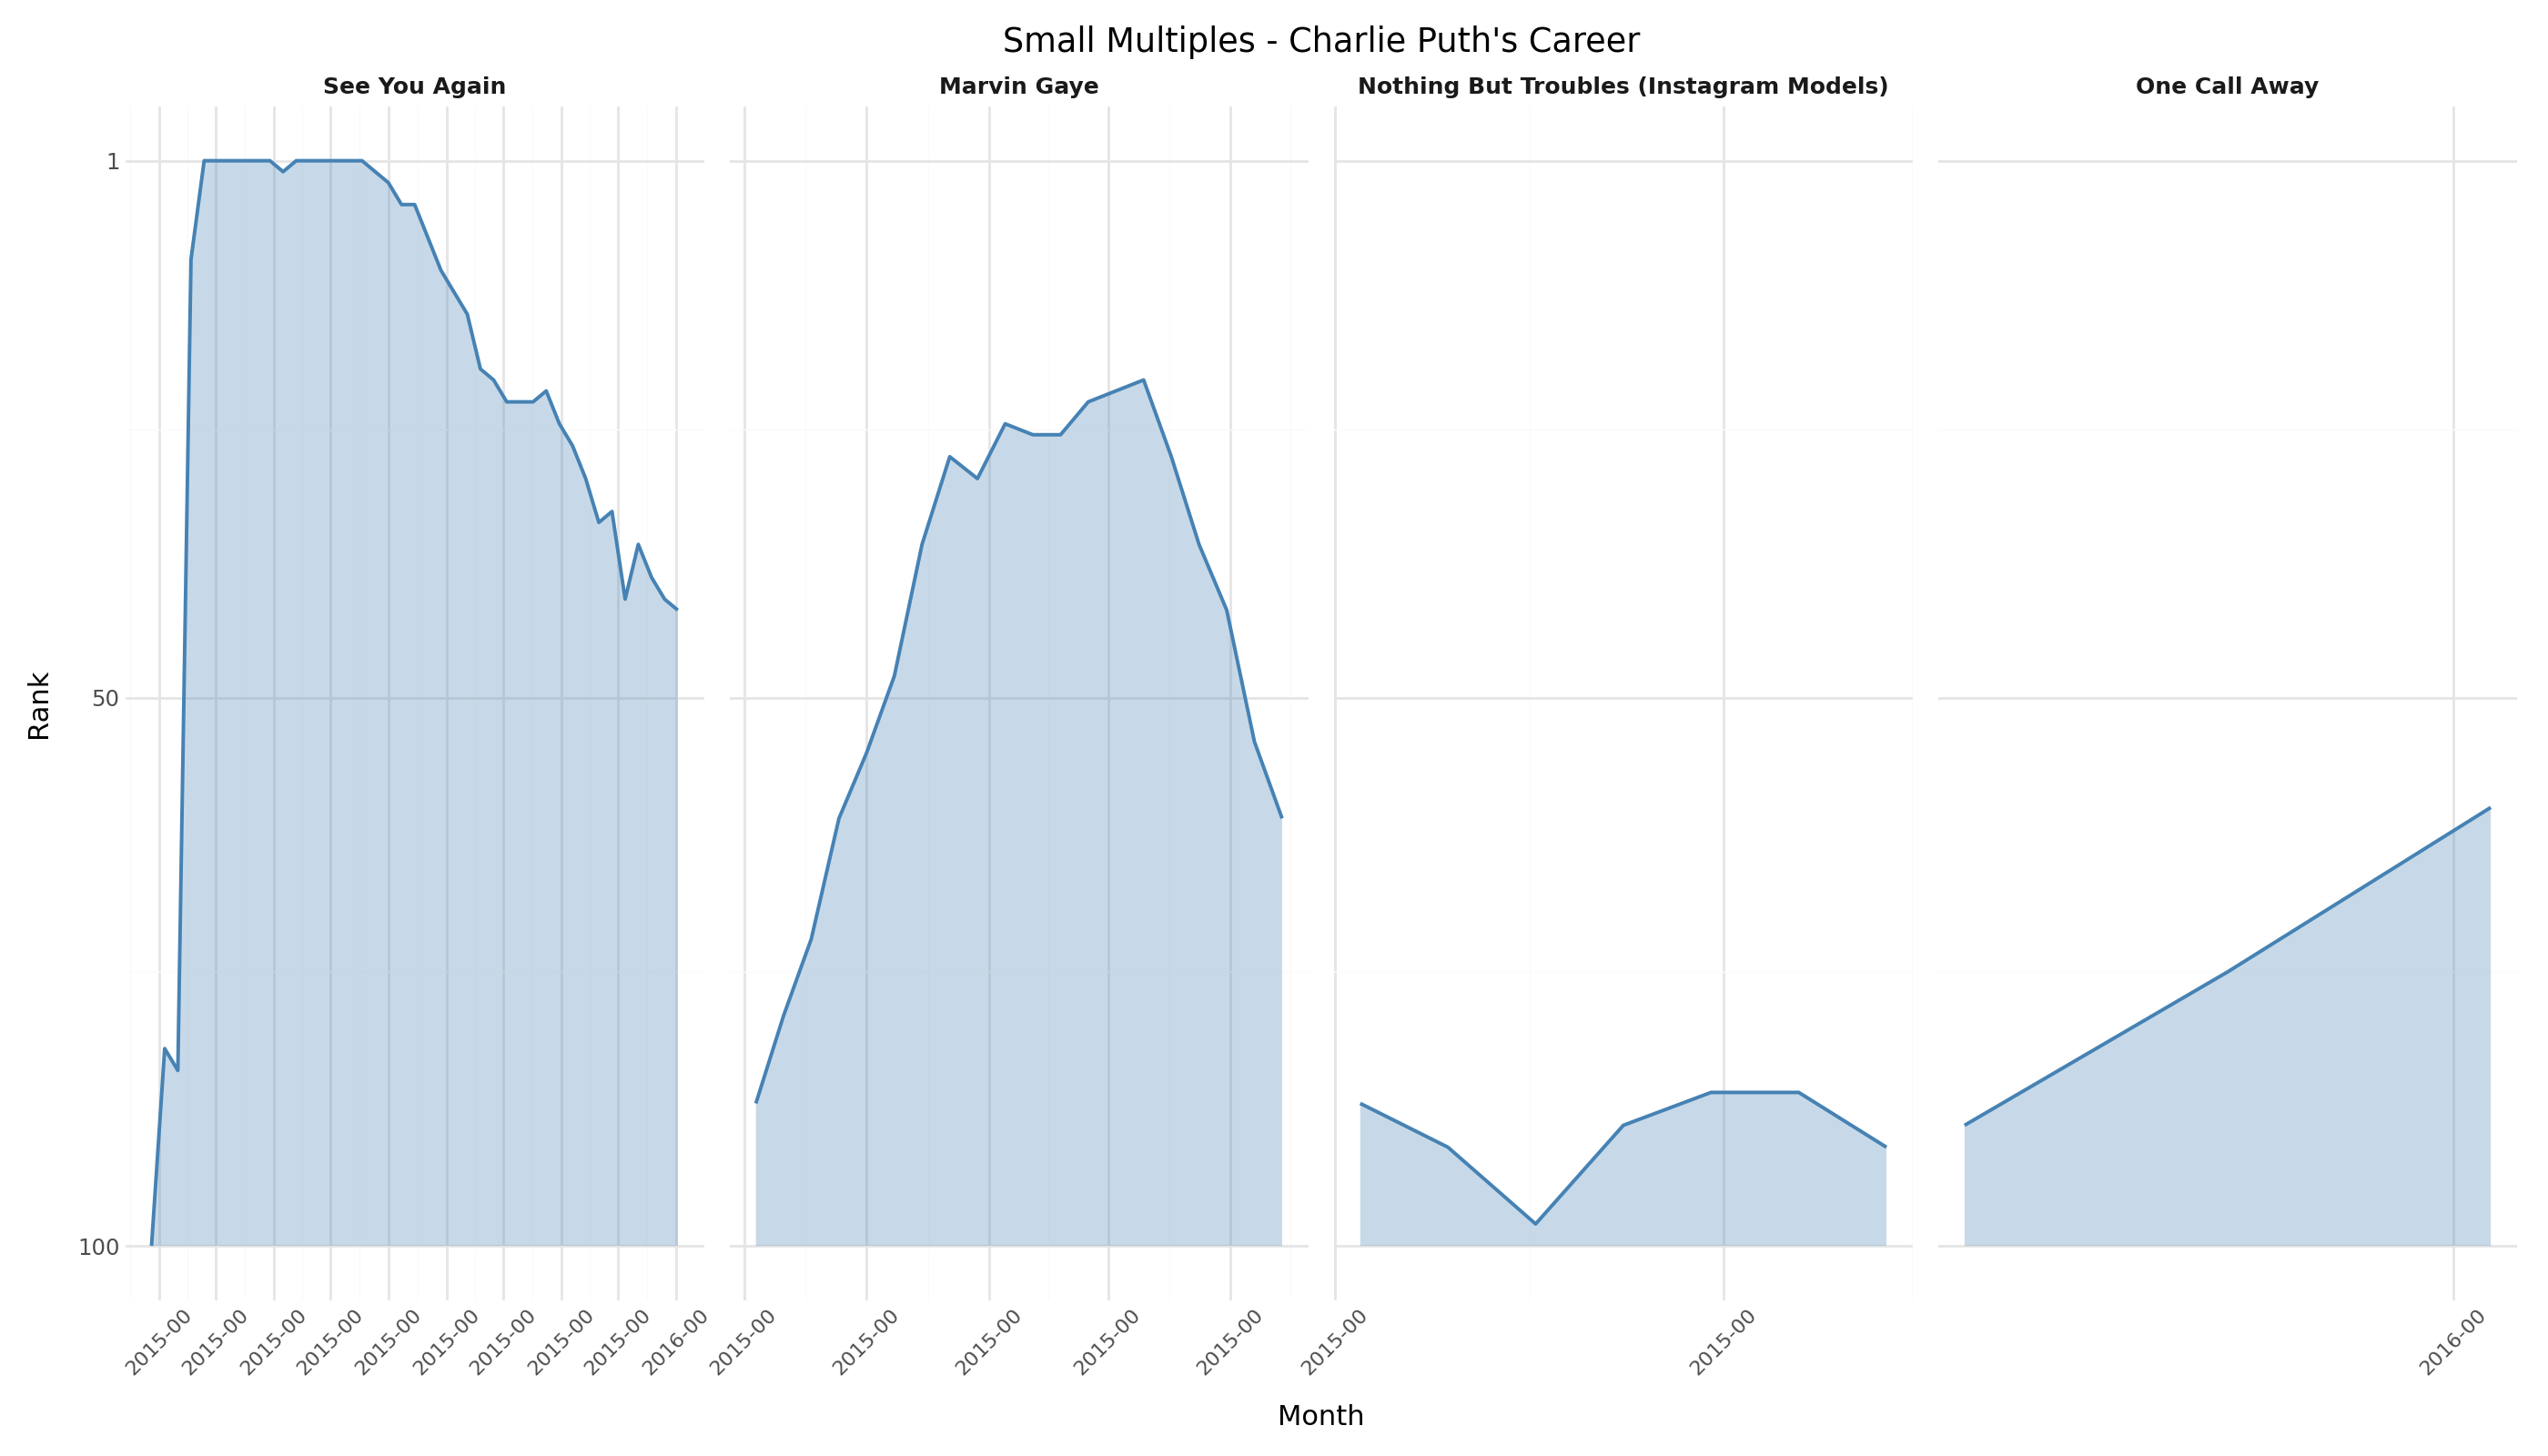

In [40]:
plot_cp_facet = (
    p9.ggplot(cp_career, p9.aes(x="week", y="this_week_position", group="song"))
    + p9.geom_line(color="#4682B4", size=0.8)
    + p9.geom_ribbon(
        p9.aes(ymin=100, ymax="this_week_position"), fill="#4682B4", alpha=0.3
    )
    + p9.scale_y_reverse(limits=(100, 1), breaks=[1, 50, 100])
    + p9.scale_x_datetime(date_breaks="1 month", date_labels="%Y-%M")
    # if want to compare time，delete scales='free_x'
    + p9.facet_wrap("~song_ordered", scales="free_x", ncol=4)
    + p9.labs(
        title="Small Multiples - Charlie Puth's Career",
        x="Month",
        y="Rank",
    )
    + p9.theme_minimal()
    + p9.theme(
        figure_size=(14, 8),
        axis_text_x=p9.element_text(angle=45, size=8),
        strip_text=p9.element_text(size=9, face="bold"),
    )
)
plot_cp_facet

Summary

The Meteoric Rise of "See You Again"

- The visualization reveals a "cliff-like" ascent, where the song rocketed from the bottom of the chart to the Number 1 spot in a matter of weeks, rather than a gradual climb. The massive blue plateau at the top of the graph represents its 12 non-consecutive weeks at #1. This visual pattern aligns perfectly with the song’s cultural context: released as a tribute to the late Paul Walker for the Furious 7 soundtrack, the track became an instant emotional anthem.

- Between the two alternative visualizations for the single-song view, the original one still remains the best for the blue area emphasize rank. While the Lollipop Chart emphasizes the "height" of the song's success relative to the bottom, the Step Chart correctly encodes the discrete nature of Billboard rankings. 

Charlie Puth’s Career 

- The graph clearly shows that his career did not follow the traditional ladder of small hits leading to big ones; instead, it began with the massive outlier of "See You Again." The visualization highlights his breakout moment in 2015, where the purple line dominates the top of the chart. However, the subsequent lines (representing hits like One Call Away and Marvin Gaye) differ in shape.They show slower climbs and steadier runs, indicating his successful pivot from a "featured artist" on a viral movie soundtrack to a standalone pop star with his own organic fanbase.

- For the two alternates, while the Heatmap effectively shows the timing of his activity, the specific color gradients make it difficult to discern the exact difference between a Top 10 hit and a Top 20 hit. The Small Multiples approach isolates each song’s lifecycle, allowing the viewer to clearly analyze the "shape" of each hit—distinguishing between songs that debuted high and fell fast versus those that were "sleeper hits" with slow climbs. 